In [2]:
import pandas as pd
from sklearn import linear_model
import numpy as np
from sklearn.model_selection import train_test_split
from matplotlib import pyplot as plt

plt.rcParams.update({'figure.figsize': (12.0, 8.0)})
plt.rcParams.update({'font.size': 14})

In [102]:
X = pd.read_csv("../data/X_train.csv").drop(['id'], axis=1)
y = pd.read_csv("../data/y_train.csv").drop(['id'], axis=1)

# impute data with average value 
X = X.fillna(X.median())
X = X.drop(X.loc[:, X.var()<0.0001].columns, axis=1) # only use columns with variance
X_norm =(X-X.mean())/X.std() # normalise the data

# test train split
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

In [6]:
# Feature selection with Lasso
n = 20
lasso_result = pd.DataFrame(columns=['alpha', 'R^2', '#coef'], index=range(n))
i = 0
for a in np.linspace(0,1.5,n):
    lasso = linear_model.Lasso(alpha=a)
    lasso.fit(X_train, y_train)
    
    lasso_result.loc[i, 'alpha'] = a
    lasso_result.loc[i, 'R^2'] = lasso.score(X_test, y_test)
    lasso_result.loc[i, '#coef'] = sum(abs(lasso.coef_) > 0.01)

    i+=1




C:\Users\juliu\AppData\Local\Temp/ipykernel_10792/1818698166.py:7: UserWarning: With alpha=0, this algorithm does not converge well. You are advised to use the LinearRegression estimator
  lasso.fit(X_train, y_train)
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: UserWarning: Coordinate descent with no regularization may lead to unexpected results and is discouraged.
  model = cd_fast.enet_coordinate_descent(
C:\Users\juliu\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:647: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.791e+03, tolerance: 9.180e+00 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
C:\Us

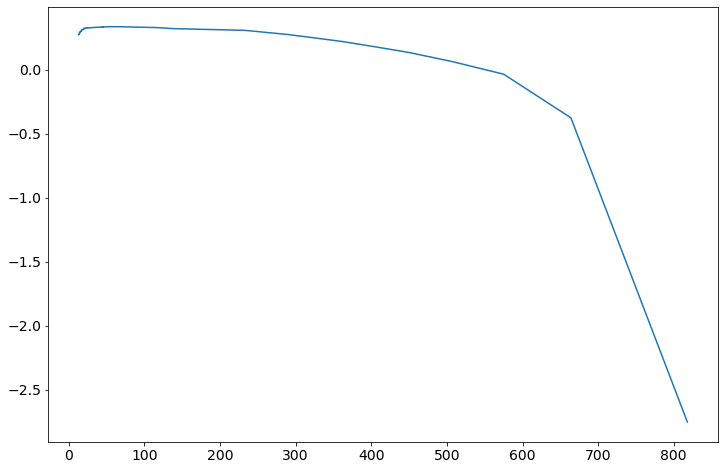

In [5]:
import matplotlib.pyplot as plt
plt.plot(lasso_result['#coef'], lasso_result['R^2'])

In [7]:
lasso_result

,alpha,R^2,#coef
0,0.0,-2.752503,818
1,0.078947,0.188822,386
2,0.157895,0.303659,239
3,0.236842,0.322774,133
4,0.315789,0.332717,86
5,0.394737,0.334623,50
6,0.473684,0.330313,35
7,0.552632,0.326592,25
8,0.631579,0.32463,22
9,0.710526,0.321998,20


In [8]:
lasso = linear_model.Lasso(alpha=0.5)
lasso.fit(X_train, y_train)
pd.DataFrame({'variable' : X.columns[abs(lasso.coef_) > 0.01], 'coef' : lasso.coef_[abs(lasso.coef_) > 0.01]}).sort_values(by='coef', ascending=False)

,variable,coef
31,x785,1.451748
1,x85,0.997589
10,x302,0.787899
12,x315,0.488188
11,x309,0.463256
30,x779,0.360995
7,x187,0.320743
8,x214,0.250698
14,x356,0.208841
25,x687,0.130881


# Feature Importance RF

In [9]:
# Let's load the packages
import numpy as np
import pandas as pd
from sklearn.datasets import load_boston
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance
import shap
from matplotlib import pyplot as plt

# Random forest feature importance
rf = RandomForestRegressor(n_estimators=100)
rf.fit(X_train, y_train.values.ravel())

RandomForestRegressor()

Text(0.5, 0, 'Random Forest Feature Importance')

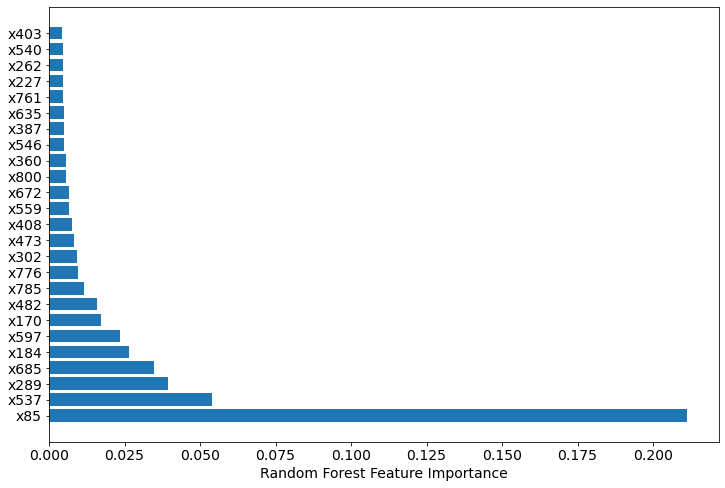

In [10]:
top = 25
sorted_idx = rf.feature_importances_.argsort()[::-1][:top]
plt.barh(X.columns[sorted_idx], rf.feature_importances_[sorted_idx])
plt.xlabel("Random Forest Feature Importance")

In [11]:
# other form of feature importance
perm_importance = permutation_importance(rf, X_test, y_test)

Text(0.5, 0, 'Permutation Importance')

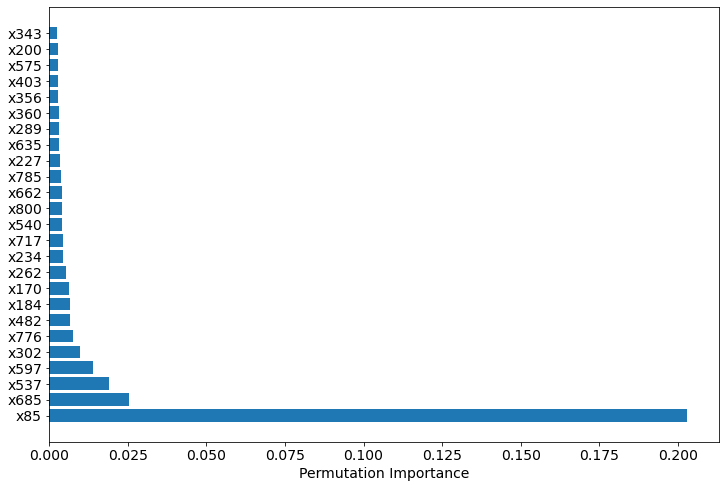

In [12]:
sorted_idx = perm_importance.importances_mean.argsort()[::-1][:top]
plt.barh(X.columns[sorted_idx], perm_importance.importances_mean[sorted_idx])
plt.xlabel("Permutation Importance")

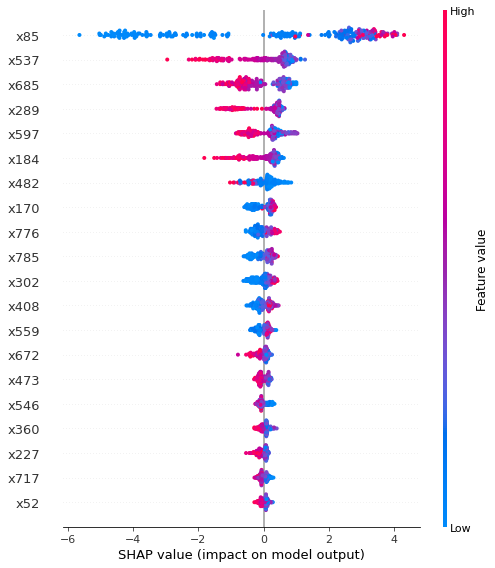

In [13]:
# third method of feature importance
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values, X_test) # , plot_type="bar"

# Figure out which interactions are good

In [108]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import KFold
from math import comb
regression = LinearRegression(normalize=True)
crossvalidation = KFold(n_splits=3, shuffle=True, random_state=1)

# cant run on all columns since it would take 5 days, hence use the top 137 lasso variables
lasso = linear_model.Lasso(alpha=0.237)
lasso.fit(X_train, y_train)
selected_features = pd.DataFrame({'variable' : X.columns[abs(lasso.coef_) > 0.001], 'coef' : lasso.coef_[abs(lasso.coef_) > 0.001]}).sort_values(by='coef', ascending=False)
df = X_norm[selected_features['variable'].values]
df.columns = df.columns.str[1:]

i=0
baseline = np.mean(cross_val_score(regression, df, y, scoring='r2', cv=crossvalidation,
 n_jobs=4))
interactions = pd.DataFrame(columns=['feature_A', 'feature_B', 'R^2'], index=range(comb(df.shape[1],2)))
for feature_A in df.columns.drop('interaction', errors='ignore'):
    for feature_B in df.columns.drop('interaction', errors='ignore'):
        if feature_A > feature_B:
            df['interaction'] = df[feature_A] * df[feature_B]
            score = np.mean(cross_val_score(regression, df, y, scoring='r2', cv=crossvalidation, n_jobs=4))

        if score > baseline:
            interactions.iloc[i, : ] = pd.Series({'feature_A' : feature_A, 'feature_B' : feature_B, 'R^2' : round(score,3)})
            i+=1


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


785 302
785 356
785 187
785 315
785 476
785 309
785 344
785 507
785 779
785 214
785 262
785 155
785 687
785 371
785 500
785 103
785 110
785 767
785 459
785 683
785 248
785 329
785 543
785 664
785 699
785 768
785 610
785 316
785 44
785 689
785 345
785 23
785 553
785 620
785 306
785 471
785 435
785 402
785 272
785 624
785 429
785 284
785 456
785 568
785 199
785 769
785 531
785 759
785 676
785 310
785 465
785 24
785 181
785 268
785 338
785 319
785 374
785 675
785 333
785 594
785 304
785 29
785 503
785 596
785 468
785 236
785 605
785 567
785 226
785 534
785 537
785 390
785 717
785 116
785 436
785 612
785 373
785 196
785 253
785 382
785 260
785 71
785 58
785 475
785 583
785 229
785 420
785 506
785 627
785 290
785 135
785 25
785 160
785 714
785 364
785 153
785 444
785 451
785 673
785 120
785 593
785 745
785 351
785 269
785 287
785 131
785 394
785 579
785 715
785 657
785 409
785 105
785 106
785 293
785 482
785 668
785 588
785 174
785 35
785 227
785 129
785 485
785 540
785 546
785 184
785 761


In [121]:
interactions.dropna(inplace=True)
print('Baseline R2: %.3f' % baseline)
print('Top 10 interactions:\n %s' % interactions.sort_values(by='R^2', ascending=False)[0:100])

Baseline R2: 0.442
Top 10 interactions:
      feature_A feature_B    R^2
4180       482       673  0.451
4179       482       451  0.451
498        687        35  0.451
330        507        95   0.45
1101       689       356   0.45
...        ...       ...    ...
1057       316        58  0.446
1056       316        71  0.446
3637         8       506  0.446
1055       316       260  0.446
4560       685       214  0.446

[100 rows x 3 columns]
